# 02 — สร้างโมเดลเรขาคณิตของห้อง (Geometry twin)

**เป้าหมาย**: จาก point cloud ดิบ → พิกัดมาตรฐานของห้อง (Z-up, ผนังขนานแกน, จุดกำเนิดที่มุมพื้น) → ตรวจจับพื้น/เพดาน/ผนัง/ชั้นปลูก → **`room_model.json`** (พารามิเตอร์ห้องที่ notebook ถัดไปทุกตัวใช้) และ point cloud ที่ทำความสะอาดแล้ว (`pfal_clean.npz`) พร้อม label

ขั้นตอน
1. Align: ปรับพื้นให้ราบ → Z-up → หมุนตามผนัง → ย้ายจุดกำเนิด (ได้เมทริกซ์ `T` 4×4 เก็บไว้ใช้แปลงพิกัดเซ็นเซอร์ภายหลัง)
2. Crop จุดนอกห้อง
3. หา peak ความสูงของระนาบแนวนอน → พื้น, ชั้นปลูก, เพดาน
4. หา footprint ของชั้นปลูก
5. บันทึกโมเดล + segment จุด + ซ้อนโมเดลกับ point cloud เพื่อตรวจสอบ

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


## 1. โหลดและ align

In [2]:
pc = io.load_ply()
T, info = G.align_room(pc["xyz"], pc["normals"])
P = G.apply_T(T, pc["xyz"]); N = G.apply_T_normals(T, pc["normals"]); RGB = pc["rgb"]
print("wall yaw corrected (deg):", round(info["wall_yaw_deg"], 2))
print("floor normal in scan frame:", np.round(info["floor_normal_scan"], 4), f"(fit on {info['floor_points']:,} pts)")
print("T (scan -> room):\n", np.round(T, 4))

wall yaw corrected (deg): 0.95
floor normal in scan frame: [ 3.0e-04  1.0e+00 -2.8e-03] (fit on 67,253 pts)
T (scan -> room):
 [[-1.6600e-02 -2.8000e-03 -9.9990e-01  1.0009e+00]
 [-9.9990e-01  3.0000e-04  1.6600e-02  4.5790e-01]
 [ 3.0000e-04  1.0000e+00 -2.8000e-03  1.4449e+00]
 [ 0.0000e+00  0.0000e+00  0.0000e+00  1.0000e+00]]


## 2. ขอบเขตภายในห้อง และ crop จุดที่อยู่นอกห้อง (สแกนทะลุประตู)

In [3]:
bounds = G.interior_bounds(P, N)
keep = G.crop_to_room(P, bounds, pad=0.15)
print(f"interior L x W x H = {bounds['L']:.3f} x {bounds['W']:.3f} x {bounds['H']:.3f} m")
print(f"kept {keep.sum():,} points, removed {(~keep).sum():,} outside the room")
P, N, RGB = P[keep], N[keep], RGB[keep]

interior L x W x H = 7.121 x 3.012 x 2.579 m
kept 1,014,282 points, removed 6,018 outside the room


## 3. ระดับความสูงของระนาบแนวนอน → พื้น / ชั้นปลูก / เพดาน

,level (m),points,class
0,0.007,40604,floor
1,0.387,21586,tier
2,0.807,16683,tier
3,1.267,16419,tier
4,1.687,12546,tier
5,2.047,12073,tier
6,2.547,15879,ceiling


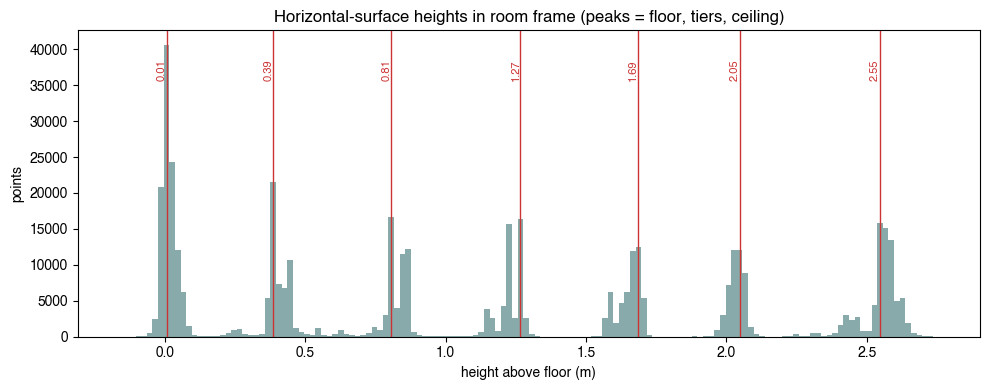

In [4]:
levels, counts, hist = G.detect_horizontal_levels(P, N)
cls = G.classify_levels(levels, bounds["H"])
fig, ax = plt.subplots(figsize=(10, 4))
viz.height_histogram(hist, levels, ax=ax, title="Horizontal-surface heights in room frame (peaks = floor, tiers, ceiling)")
fig.tight_layout(); fig.savefig(FIG / "02_levels.png", dpi=150)
pd.DataFrame({"level (m)": np.round(levels, 3), "points": counts,
              "class": ["floor" if abs(l - cls["floor"]) < 1e-9 else "ceiling" if abs(l - cls["ceiling"]) < 1e-9
                        else "top frame" if abs(l - cls["top_frame"]) < 1e-9 else "tier" for l in levels]})

## 4. Footprint ของชั้นปลูก (จากจุดแนวนอนที่แต่ละระดับชั้น)

In [5]:
rack = G.rack_footprint(P, N, cls["tiers"])
per_tier = pd.DataFrame(rack["per_tier"]).round(3)
per_tier.index = [f"tier {i+1}" for i in range(len(per_tier))]
print(f"rack (median over tiers): x {rack['x0']:.2f}–{rack['x1']:.2f} m, y {rack['y0']:.2f}–{rack['y1']:.2f} m "
      f"→ {rack['x1']-rack['x0']:.2f} x {rack['y1']-rack['y0']:.2f} m")
print(f"aisles: left {rack['y0']:.2f} m, right {bounds['W']-rack['y1']:.2f} m")
per_tier

rack (median over tiers): x 0.77–6.20 m, y 1.01–2.05 m → 5.43 x 1.04 m
aisles: left 1.01 m, right 0.96 m


,z,x0,x1,y0,y1,n
tier 1,0.387,0.771,6.956,0.900,2.086,34266
tier 2,0.807,0.841,6.297,0.541,2.054,23706
tier 3,1.267,0.723,6.202,1.075,2.019,21695
tier 4,1.687,0.764,6.184,1.010,2.050,29908
tier 5,2.047,0.776,6.026,1.031,2.872,33009


ชั้นที่ footprint กว้างกว่าปกติ (เช่นชั้นล่างสุดยาวถึงผนัง) เกิดจากถัง/อุปกรณ์ที่อยู่ระดับเดียวกัน — จึงใช้ค่า median ของทุกชั้นเป็นขนาด rack

## 5. ทำให้โมเดลสมมาตร แล้วบันทึก `room_model.json`
ห้องจริงเป็นสี่เหลี่ยมมุมฉากและชั้นปลูกอยู่กึ่งกลางความกว้างห้อง — ค่าที่วัดจากสแกนต่างจากสมมาตรเพียงไม่กี่ซม. (noise ของ LiDAR)
จึง **บังคับสมมาตรในโมเดล**: rack อยู่กึ่งกลาง Y พอดี (ทางเดินสองข้างเท่ากัน) และปัดขนาดเป็น 1 ซม. ค่าที่วัดได้จริงเก็บไว้ใน `model["measured"]`
ตามความยาว (X) ไม่บังคับ เพราะปลายห้องด้านหนึ่งมีถัง/อุปกรณ์ → ถ้าหน้างาน rack อยู่กึ่งกลางความยาวด้วย ให้ตั้ง `centre_length=True`

In [6]:
measured = G.build_room_model(bounds, cls, rack, T, info)
model = G.symmetrize_model(measured, centre_width=True, centre_length=False, round_to=0.01)
cmp = pd.DataFrame({
    "measured": dict(room_W=measured["room"]["W"], rack_y0=measured["rack"]["y0"], rack_y1=measured["rack"]["y1"],
                     aisle_left=measured["rack"]["y0"], aisle_right=measured["room"]["W"] - measured["rack"]["y1"],
                     rack_centre_offset=(measured["rack"]["y0"] + measured["rack"]["y1"]) / 2 - measured["room"]["W"] / 2),
    "model (symmetric)": dict(room_W=model["room"]["W"], rack_y0=model["rack"]["y0"], rack_y1=model["rack"]["y1"],
                     aisle_left=model["rack"]["y0"], aisle_right=model["room"]["W"] - model["rack"]["y1"],
                     rack_centre_offset=(model["rack"]["y0"] + model["rack"]["y1"]) / 2 - model["room"]["W"] / 2),
}).round(3)
path = io.save_model(model)
print("saved", path)
display(cmp)
import json; print(json.dumps({k: v for k, v in model.items() if k not in ("transform_scan_to_room", "measured")}, indent=2, ensure_ascii=False))

saved /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/data/model/room_model.json


,measured,model (symmetric)
room_W,3.012,3.010
rack_y0,1.010,0.985
rack_y1,2.054,2.025
aisle_left,1.010,0.985
aisle_right,0.958,0.985
rack_centre_offset,0.026,0.000


{
  "source": "SIS PFAL.ply",
  "frame": "room: Z up, X = length, Y = width, origin = interior floor corner (m)",
  "room": {
    "L": 7.12,
    "W": 3.01,
    "H": 2.58
  },
  "rack": {
    "x0": 0.771,
    "x1": 6.202,
    "y0": 0.985,
    "y1": 2.025,
    "length": 5.43,
    "width": 1.04,
    "tiers": [
      {
        "index": 1,
        "z": 0.387
      },
      {
        "index": 2,
        "z": 0.807
      },
      {
        "index": 3,
        "z": 1.267
      },
      {
        "index": 4,
        "z": 1.687
      },
      {
        "index": 5,
        "z": 2.047
      }
    ],
    "top_frame_z": 2.58
  },
  "alignment_info": {
    "wall_yaw_deg": 0.952,
    "floor_normal_scan": [
      0.0002800000074785203,
      1.0,
      -0.00279000005684793
    ]
  },
  "idealised": {
    "centre_width": true,
    "centre_length": false,
    "round_to": 0.01
  }
}


## 6. Segment จุดเป็น พื้น / เพดาน / ผนัง 4 ด้าน / ชั้นปลูกแต่ละชั้น

In [7]:
labels = G.segment_points(P, N, model)
names = G.label_names(model)
u, c = np.unique(labels, return_counts=True)
seg = pd.DataFrame({"label": [names[k] for k in u], "points": c, "share %": (100 * c / c.sum()).round(1)})
seg

,label,points,share %
0,other,419063,41.3
1,floor,101383,10.0
2,ceiling,65438,6.5
3,wall_x0,29844,2.9
4,wall_x1,50577,5.0
5,wall_y0,89704,8.8
6,wall_y1,102301,10.1
7,tier_1,31253,3.1
8,tier_2,26669,2.6
9,tier_3,26578,2.6


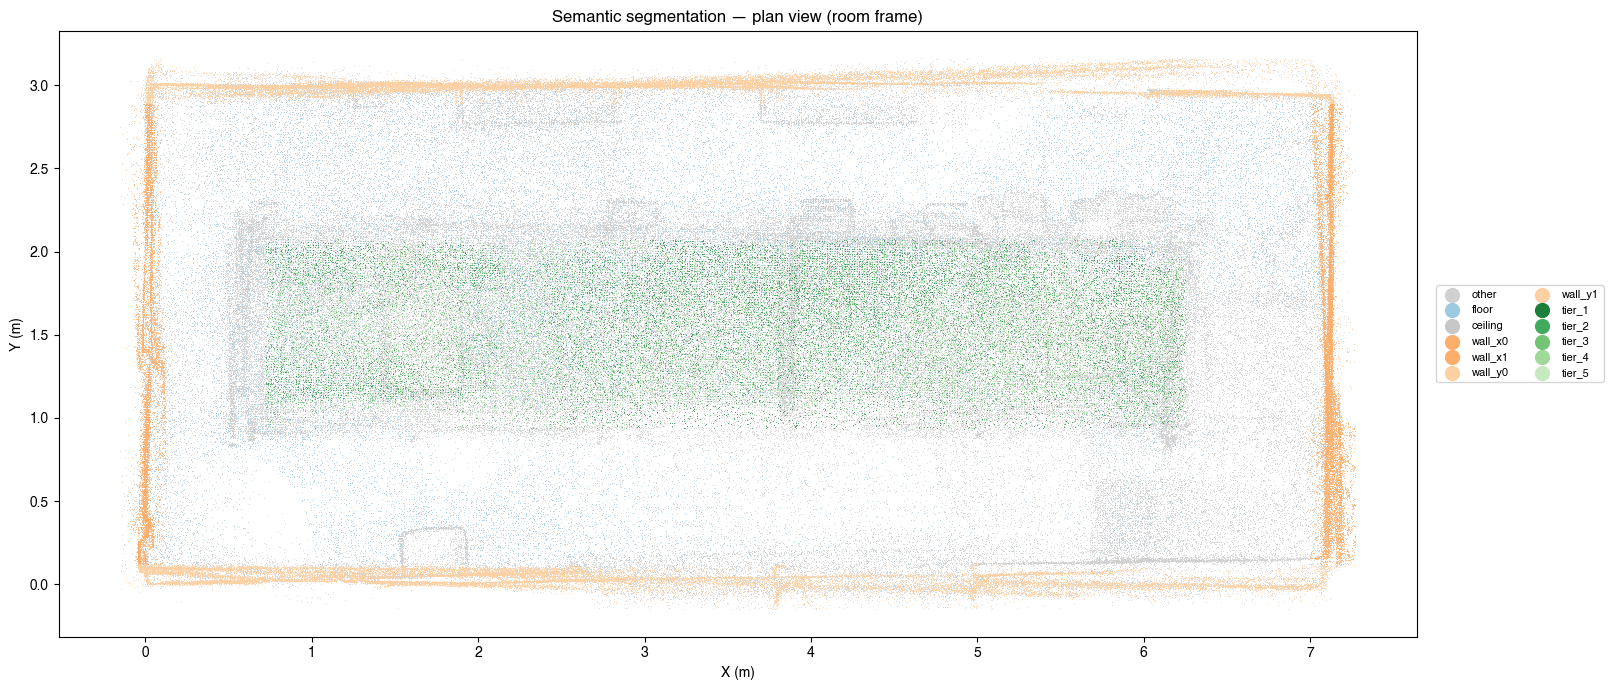

In [8]:
# plan view coloured by label (English labels for publication)
palette = {0: "#d0d0d0", 1: "#9ecae1", 2: "#c7c7c7", 3: "#fdae6b", 4: "#fdae6b", 5: "#fdd0a2", 6: "#fdd0a2"}
tier_cols = ["#1b7f3b", "#41ab5d", "#74c476", "#a1d99b", "#c7e9c0", "#e5f5e0"]
for t in model["rack"]["tiers"]: palette[10 + t["index"]] = tier_cols[(t["index"] - 1) % len(tier_cols)]
idx = viz.subsample(len(P), 300000)
fig, ax = plt.subplots(figsize=(16, 7))
for k in u:
    m = labels[idx] == k
    ax.scatter(P[idx][m, 0], P[idx][m, 1], s=0.3, c=palette[k], label=names[k], linewidths=0)
ax.set_aspect("equal"); ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_title("Semantic segmentation — plan view (room frame)")
ax.legend(markerscale=20, ncol=2, fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.tight_layout(); fig.savefig(FIG / "02_segmentation_plan.png", dpi=150)

## 7. ตรวจสอบ: ซ้อน parametric model (กล่องห้อง + ชั้นปลูก) บน point cloud

In [9]:
traces = [viz.points_trace(P, RGB, n=80000, size=1.4, name="point cloud")] + viz.model_traces(model)
fig3d = viz.figure_3d(traces, title="Parametric room model over the aligned point cloud (room frame, Z up)")
viz.show3d(fig3d, "02_room_model")

full-window version: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/02_room_model.html   (open in a browser)


PosixPath('/Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/02_room_model.html')

ถ้าแผ่นสีเขียว (ชั้นปลูก) และกรอบห้องทับกับจุดพอดี แปลว่า alignment และการตรวจจับใช้ได้ — ตัวเลขทั้งหมดอยู่ใน `room_model.json`

## 8. ตรวจความแม่นยำเชิงตัวเลข: ระยะเบี่ยงเบนของจุดผนัง/พื้น/เพดานจากระนาบโมเดล

In [10]:
L, W, H = model["room"]["L"], model["room"]["W"], model["room"]["H"]
resid = {
    "floor (z=0)": P[labels == 1, 2], "ceiling (z=H)": P[labels == 2, 2] - H,
    "wall x=0": P[labels == 3, 0], "wall x=L": P[labels == 4, 0] - L,
    "wall y=0": P[labels == 5, 1], "wall y=W": P[labels == 6, 1] - W,
}
pd.DataFrame({k: dict(n=len(v), mean_cm=100 * v.mean(), std_cm=100 * v.std(), p95_abs_cm=100 * np.percentile(np.abs(v), 95))
              for k, v in resid.items()}).T.round(2)

,n,mean_cm,std_cm,p95_abs_cm
floor (z=0),101383.0,0.99,1.86,4.20
ceiling (z=H),65438.0,-0.72,3.28,6.29
wall x=0,29844.0,1.17,3.59,8.55
wall x=L,50577.0,-0.09,3.73,8.10
wall y=0,89704.0,3.47,4.34,10.12
wall y=W,102301.0,-0.61,4.28,9.17


std ระดับ 2–4 ซม. เป็นค่าปกติของ LiDAR มือถือ — ถ้าค่า mean ห่างจาก 0 มากกว่า ~3 ซม. แปลว่าตำแหน่งผนังในโมเดลควรปรับ

### ความไม่ตั้งฉากของผนังจาก scan drift
LiDAR มือถือสะสม drift ระหว่างเดินสแกน ทำให้ผนังที่จริงขนานกันอาจไม่ขนานในข้อมูล ตรวจด้วยการ fit เส้นผ่านจุดผนังแต่ละด้าน:
`tilt_deg` = มุมเอียงที่เหลือหลัง align, `span_cm` = ระยะที่ผนังเบี่ยงไปตลอดความยาว

In [11]:
tilts = pd.DataFrame(G.wall_tilts(P, N, model)).T.round(2)
tilts

,tilt_deg,offset_cm,span_cm,n
wall y=0,0.18,4.91,2.39,94337.0
wall y=W,0.08,-1.02,1.03,96403.0
wall x=0,0.26,2.55,1.41,36147.0
wall x=L,0.16,-2.54,0.87,47785.0


ถ้า `span_cm` อยู่ในระดับ ≤ 10 ซม. การใช้กล่องสี่เหลี่ยมแทนห้องยังเหมาะสมสำหรับ twin (โซนปลูกกว้างระดับเมตร) — แต่ควรรายงานเป็นข้อจำกัดของข้อมูลในบทความ และหากต้องการความแม่นยำสูงกว่านี้ ให้สแกนใหม่แบบวนปิด loop (loop closure) หรือใช้ terrestrial scanner

## 9. ตรวจสอบข้ามกับสแกนชุดที่ 2 (`SIS PFAL2.ply`, สแกนซ้ำห้องเดิม 13 ก.ย. 2026)
ไฟล์ที่ 2 ไม่มี normal (ประมาณด้วย open3d) — รัน pipeline เดียวกันแล้วเทียบขนาดห้อง/ชั้น/rack กับสแกนแรก เพื่อประเมินความคลาดเคลื่อนของ LiDAR มือถือแบบอิสระ

In [12]:
pc2 = io.load_ply(io.RAW / "pointcloud" / "SIS PFAL2.ply")
T2, info2 = G.align_room(pc2["xyz"], pc2["normals"])
P2 = G.apply_T(T2, pc2["xyz"]); N2 = G.apply_T_normals(T2, pc2["normals"])
b2 = G.interior_bounds(P2, N2); k2 = G.crop_to_room(P2, b2); P2, N2 = P2[k2], N2[k2]
lv2, _, _ = G.detect_horizontal_levels(P2, N2); cls2 = G.classify_levels(lv2, b2["H"]); rack2 = G.rack_footprint(P2, N2, cls2["tiers"])
rows = {"room L": (measured["room"]["L"], b2["L"]), "room W": (measured["room"]["W"], b2["W"]), "room H": (measured["room"]["H"], b2["H"]),
        "rack length": (measured["rack"]["length"], rack2["x1"] - rack2["x0"]), "rack width": (measured["rack"]["width"], rack2["y1"] - rack2["y0"]),
        "rack x0": (measured["rack"]["x0"], rack2["x0"]), "rack y0": (measured["rack"]["y0"], rack2["y0"])}
for t1, z2 in zip(measured["rack"]["tiers"], cls2["tiers"]):
    rows[f"tier {t1['index']} z"] = (t1["z"], z2)
rows["top frame z"] = (measured["rack"]["top_frame_z"], cls2["top_frame"])
cmp2 = pd.DataFrame(rows, index=["scan 1 (SIS PFAL.ply)", "scan 2 (SIS PFAL2.ply)"]).T
cmp2["diff cm"] = 100 * (cmp2.iloc[:, 1] - cmp2.iloc[:, 0])
cmp2.round(3).to_csv(io.MODEL_DIR / "scan_comparison.csv")
print(f"scan 2: {len(pc2['xyz']):,} points, {k2.sum():,} inside the room | max |diff| = {cmp2['diff cm'].abs().max():.1f} cm")
cmp2.round(3)

scan 2: 963,639 points, 958,740 inside the room | max |diff| = 8.0 cm


,scan 1 (SIS PFAL.ply),scan 2 (SIS PFAL2.ply),diff cm
room L,7.121,7.151,3.045
room W,3.012,3.086,7.365
room H,2.579,2.573,-0.552
rack length,5.430,5.402,-2.826
rack width,1.044,1.124,8.001
rack x0,0.771,0.748,-2.258
rack y0,1.010,0.992,-1.755
tier 1 z,0.387,0.381,-0.584
tier 2 z,0.807,0.821,1.416
tier 3 z,1.267,1.221,-4.584


ทั้งสองสแกนต่างกันระดับ ≤ 5–8 ซม. (ผนัง W ต่างมากสุดเพราะ scan drift) — ยืนยันว่า `room_model.json` จากสแกนแรกใช้ได้ และเป็นตัวเลขความไม่แน่นอนที่ควรรายงานในบทความ

## 9b. เทียบกับแปลนออกแบบ (`data/raw/doc/Plan Layout PFAL SISKU.pdf` — แปลนที่ใช้วางแผน ไม่ใช่ as-built)
ค่าจากแปลนเก็บใน `data/model/design_spec.json` รายละเอียดใน `docs/DESIGN_VS_BUILT.md`

In [13]:
design = io.load_model("design_spec.json")["room_design"]
cmp3 = pd.DataFrame({"design drawing (m)": [design["L"], design["W"], design["H"]],
                     "as-built scan 1 (m)": [measured["room"]["L"], measured["room"]["W"], measured["room"]["H"]],
                     "as-built scan 2 (m)": [b2["L"], b2["W"], b2["H"]]}, index=["room L", "room W", "room H"]).round(2)
cmp3["built - design (m)"] = (cmp3["as-built scan 1 (m)"] - cmp3["design drawing (m)"]).round(2)
cmp3

,design drawing (m),as-built scan 1 (m),as-built scan 2 (m),built - design (m)
room L,8.90,7.12,7.15,-1.78
room W,3.00,3.01,3.09,0.01
room H,2.85,2.58,2.57,-0.27


ความยาวต่างกัน 1.78 ม. **ไม่ใช่สร้างสั้นกว่า** — อาคารยาว 8.9 ม. ตามแปลน แต่ถูกกั้นเป็น**ห้องหน้าสำหรับวางซิงค์ (~1.78 ม.)** ก่อนถึงประตูห้องปลูก ซึ่ง point cloud ไม่ได้สแกน (ผังใน notebook 03 แสดงเป็นพื้นที่ 'not scanned'); ความสูงต่ำกว่าแปลน 0.27 ม. จำนวนถาด/LED ต่อชั้นในแปลน (141 โมดูล) จึงใช้กับ rack จริง 5.43 ม. ไม่ได้โดยตรง ต้องนับหน้างาน

## 10. บันทึก point cloud ที่ทำความสะอาดแล้ว + label

In [14]:
out = io.save_clean(P, N, RGB, labels)
print("saved", out, f"({out.stat().st_size/1e6:.1f} MB)")

saved /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/data/processed/pfal_clean.npz (24.7 MB)


## สิ่งที่ควรยืนยันด้วยตลับเมตร (เขียนค่าจริงลง `room_model.json` ถ้าต่างกัน)
| รายการ | ค่าจากสแกน |
|---|---|
| ความยาวห้อง (L) | ดูข้อ 2 |
| ความกว้างห้อง (W) | ดูข้อ 2 |
| ความสูงพื้น–เพดาน (H) | ดูข้อ 2 |
| ขนาดชั้นปลูก (ยาว × กว้าง) | ดูข้อ 4 |
| ความสูงชั้น 1–5 จากพื้น | ดูข้อ 3 |

**ถัดไป — Notebook 03**: แบ่งโซน (ชั้น × ช่วงความยาว) และวางตำแหน่งเซ็นเซอร์ XY-MD02 ทั้ง 5 ตัว, CO₂ controller, Grow Controller ลงในพิกัดห้องนี้